In [207]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt

In [208]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\SVM\titanic\Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [209]:
df.duplicated().sum()

np.int64(0)

In [210]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

drop cabin

In [211]:
df=df.drop(columns='Cabin')

In [212]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [213]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [214]:
df.dropna()['Survived'].value_counts()

Survived
0    424
1    288
Name: count, dtype: int64

125-54

In [215]:
df_copy = df.copy()
df_copy

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [216]:
df.dropna(inplace=True)

In [217]:
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [218]:
df["Marital_Status"] = df["Name"].str.extract(r",\s*(\w+)\.")

In [219]:
df.dtypes

PassengerId         int64
Survived            int64
Pclass              int64
Name               object
Sex                object
Age               float64
SibSp               int64
Parch               int64
Ticket             object
Fare              float64
Embarked           object
Marital_Status     object
dtype: object

In [220]:
print(df[df['Age']<18])

     PassengerId  Survived  Pclass                                     Name  \
7              8         0       3           Palsson, Master. Gosta Leonard   
9             10         1       2      Nasser, Mrs. Nicholas (Adele Achem)   
10            11         1       3          Sandstrom, Miss. Marguerite Rut   
14            15         0       3     Vestrom, Miss. Hulda Amanda Adolfina   
16            17         0       3                     Rice, Master. Eugene   
..           ...       ...     ...                                      ...   
850          851         0       3  Andersson, Master. Sigvard Harald Elias   
852          853         0       3                  Boulos, Miss. Nourelain   
853          854         1       1                Lines, Miss. Mary Conover   
869          870         1       3          Johnson, Master. Harold Theodor   
875          876         1       3         Najib, Miss. Adele Kiamie "Jane"   

        Sex   Age  SibSp  Parch    Ticket     Fare 

In [221]:
df['Marital_Status'].value_counts()

Marital_Status
Mr          398
Miss        145
Mrs         107
Master       36
Rev           6
Dr            6
Mlle          2
Major         2
Col           2
Don           1
Mme           1
Ms            1
Sir           1
Lady          1
Capt          1
Jonkheer      1
Name: count, dtype: int64

In [222]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Marital_Status
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q,Mrs
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr


In [223]:
df.drop(columns=['PassengerId', 'Name', 'Marital_Status', 'Ticket'], inplace=True)

In [224]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
889,1,1,male,26.0,0,0,30.0000,C


In [225]:
def age_category(Age):
    if Age<12:
        return 'child'
    elif Age>=12 and Age<18:
        return 'teenager'
    elif Age>=18 and Age<60:
        return 'adult'
    elif Age>=60:
        return 'senior'
    else:
        return 'unknown'
df['age_category'] = df['Age'].apply(func=age_category)

In [226]:
df['age_category'].value_counts()

age_category
adult       574
child        68
teenager     45
senior       25
Name: count, dtype: int64

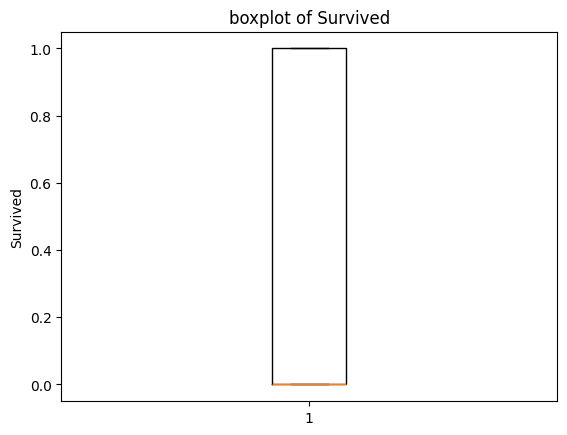

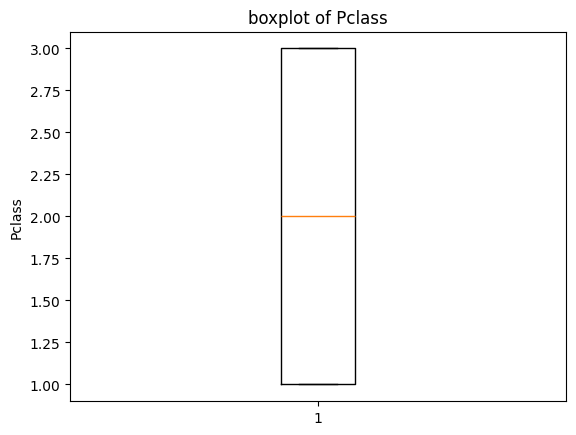

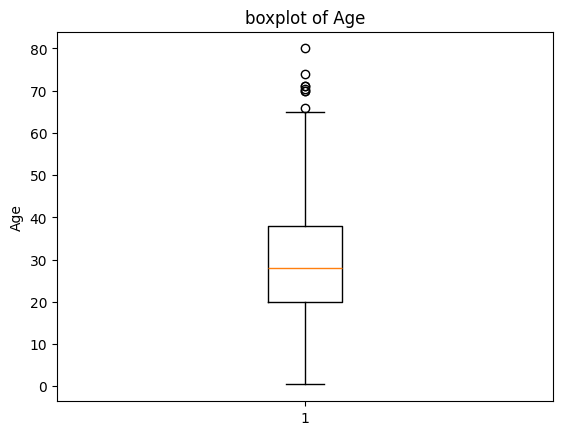

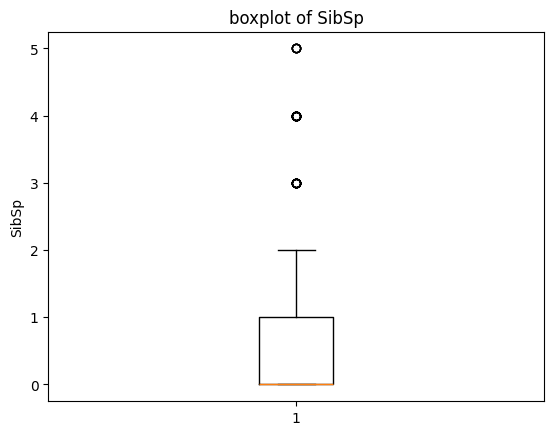

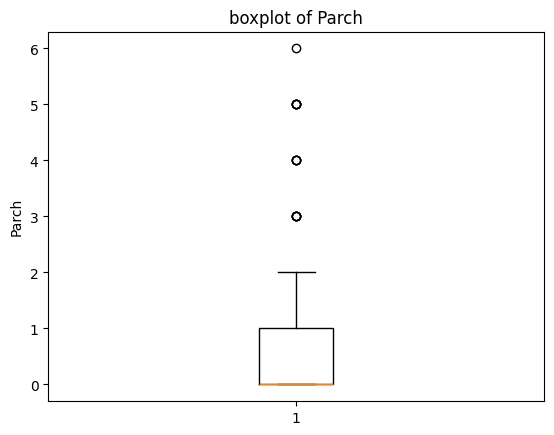

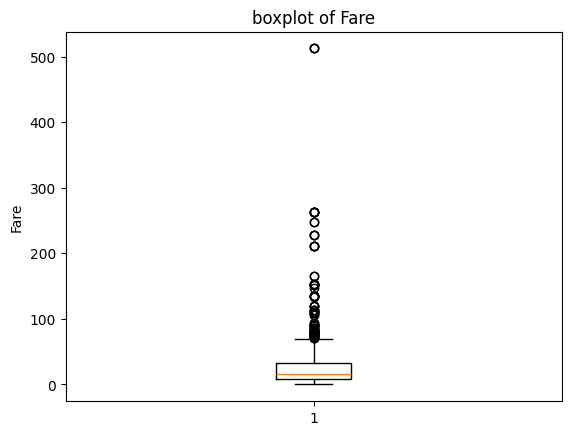

In [227]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.boxplot(df[i])
        plt.title(f'boxplot of {i}')
        plt.ylabel(i)
        plt.show()

In [228]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [229]:
label=[]
for i in df:
    if df[i].nunique()==2 and df[i].dtype=='object':
        label.append(i)
label

['Sex']

In [230]:
label_dict={}
for i in label:
    label_dict[i]=LabelEncoder()
    df[i]=label_dict[i].fit_transform(df[i])
label_dict

{'Sex': LabelEncoder()}

In [231]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age_category
0,0,3,1,22.0,1,0,7.2500,S,adult
1,1,1,0,38.0,1,0,71.2833,C,adult
2,1,3,0,26.0,0,0,7.9250,S,adult
3,1,1,0,35.0,1,0,53.1000,S,adult
4,0,3,1,35.0,0,0,8.0500,S,adult
...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,Q,adult
886,0,2,1,27.0,0,0,13.0000,S,adult
887,1,1,0,19.0,0,0,30.0000,S,adult
889,1,1,1,26.0,0,0,30.0000,C,adult


<Axes: >

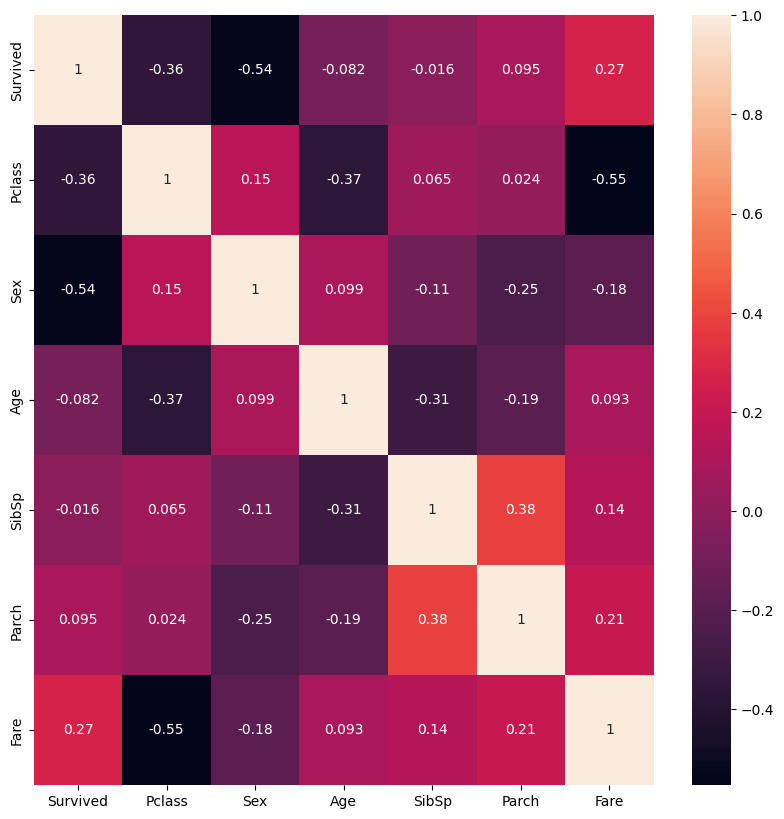

In [232]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [233]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [234]:
onehot=OneHotEncoder(sparse_output=False, drop='first')
res=onehot.fit_transform(df[['Embarked']])
res

array([[0., 1.],
       [0., 0.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 0.],
       [1., 0.]], shape=(712, 2))

In [235]:
res=pd.DataFrame(res, columns=onehot.get_feature_names_out())
res.shape
res

,Embarked_Q,Embarked_S
0,0.0,1.0
1,0.0,0.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
707,1.0,0.0
708,0.0,1.0
709,0.0,1.0
710,0.0,0.0


In [236]:
df.drop(columns=['Embarked'], inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,age_category
0,0,3,1,22.0,1,0,7.2500,adult
1,1,1,0,38.0,1,0,71.2833,adult
2,1,3,0,26.0,0,0,7.9250,adult
3,1,1,0,35.0,1,0,53.1000,adult
4,0,3,1,35.0,0,0,8.0500,adult
...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,adult
886,0,2,1,27.0,0,0,13.0000,adult
887,1,1,0,19.0,0,0,30.0000,adult
889,1,1,1,26.0,0,0,30.0000,adult


In [237]:
df.reset_index(drop=True, inplace=True)
df = df.join(res)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,age_category,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,adult,0.0,1.0
1,1,1,0,38.0,1,0,71.2833,adult,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,adult,0.0,1.0
3,1,1,0,35.0,1,0,53.1000,adult,0.0,1.0
4,0,3,1,35.0,0,0,8.0500,adult,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
707,0,3,0,39.0,0,5,29.1250,adult,1.0,0.0
708,0,2,1,27.0,0,0,13.0000,adult,0.0,1.0
709,1,1,0,19.0,0,0,30.0000,adult,0.0,1.0
710,1,1,1,26.0,0,0,30.0000,adult,0.0,0.0


In [238]:
onehot=OneHotEncoder(sparse_output=False, drop='first')
res=onehot.fit_transform(df[['age_category']])
res=pd.DataFrame(res, columns=onehot.get_feature_names_out())
df.drop(columns=['age_category'], inplace=True)
df.reset_index(drop=True, inplace=True)
df = df.join(res)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,age_category_child,age_category_senior,age_category_teenager
0,0,3,1,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,0.0
1,1,1,0,38.0,1,0,71.2833,0.0,0.0,0.0,0.0,0.0
2,1,3,0,26.0,0,0,7.9250,0.0,1.0,0.0,0.0,0.0
3,1,1,0,35.0,1,0,53.1000,0.0,1.0,0.0,0.0,0.0
4,0,3,1,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
707,0,3,0,39.0,0,5,29.1250,1.0,0.0,0.0,0.0,0.0
708,0,2,1,27.0,0,0,13.0000,0.0,1.0,0.0,0.0,0.0
709,1,1,0,19.0,0,0,30.0000,0.0,1.0,0.0,0.0,0.0
710,1,1,1,26.0,0,0,30.0000,0.0,0.0,0.0,0.0,0.0


In [239]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [240]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled = minmax.fit_transform(x)

In [241]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.3, random_state=5)

KNeighborsClassifier()
----------------------------
81.30841121495327
[[121  15]
 [ 25  53]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       136
           1       0.78      0.68      0.73        78

    accuracy                           0.81       214
   macro avg       0.80      0.78      0.79       214
weighted avg       0.81      0.81      0.81       214



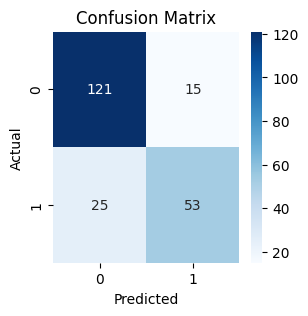


SVC()
----------------------------
81.77570093457945
[[120  16]
 [ 23  55]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       136
           1       0.77      0.71      0.74        78

    accuracy                           0.82       214
   macro avg       0.81      0.79      0.80       214
weighted avg       0.82      0.82      0.82       214



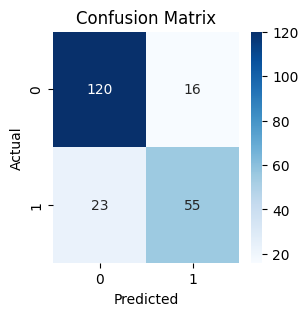


SVC(C=1000)
----------------------------
78.50467289719626
[[115  21]
 [ 25  53]]
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       136
           1       0.72      0.68      0.70        78

    accuracy                           0.79       214
   macro avg       0.77      0.76      0.77       214
weighted avg       0.78      0.79      0.78       214



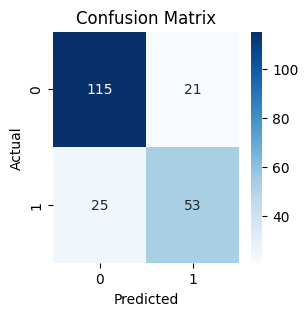

In [242]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

models=[KNeighborsClassifier(), SVC(), SVC(C=1000)]
for model in models:
    model.fit(x_train, y_train)
    y_pred=model.predict(x_test)
    print(model)
    print("----------------------------")
    print(accuracy_score(y_test, y_pred)*100)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    plt.figure(figsize=(3,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), fmt='d', cmap='Blues', annot=True)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print()